In [1]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


In [8]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari


pari.allocatemem(6*10**9) 
print(f"PARI stack size set to: {pari.stacksize() / 1e9:.2f} GB")


D = delta_qexp(545) 
print(nth_prime(100))
print(D[nth_prime(100)])

PARI stack size set to 6000000000 bytes, maximum size set to 6000001024
PARI stack size set to: 6.00 GB
541
-1695266465052058


In [27]:
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


n: 1 elapsed: 0.0015836993853251139
n: 2 elapsed: 0.0016036351521809896
n: 3 elapsed: 0.001607815424601237
n: 4 elapsed: 0.0016120473543802898
n: 5 elapsed: 0.0016242663065592449
n: 6 elapsed: 0.0016361157099405925
n: 7 elapsed: 0.0016818960507710774
n: 8 elapsed: 0.0017242153485616048
n: 9 elapsed: 0.0017939130465189615
n: 10 elapsed: 0.0018565853436787922
n: 11 elapsed: 0.0019137978553771973
n: 12 elapsed: 0.0020295500755310057
n: 13 elapsed: 0.002088646094004313
n: 14 elapsed: 0.0021919806798299155
n: 15 elapsed: 0.002374748388926188
n: 16 elapsed: 0.0025675694147745767
n: 17 elapsed: 0.0027003804842631023
n: 18 elapsed: 0.0028386672337849935
n: 19 elapsed: 0.0031168341636657717
n: 20 elapsed: 0.0033080021540323893
n: 21 elapsed: 0.003480184078216553
n: 22 elapsed: 0.0038959463437398274
n: 23 elapsed: 0.004122583071390787
n: 24 elapsed: 0.004667119185129801
n: 25 elapsed: 0.0050231138865153
n: 26 elapsed: 0.005418447653452555
n: 27 elapsed: 0.005803434054056803
n: 28 elapsed: 0.0062

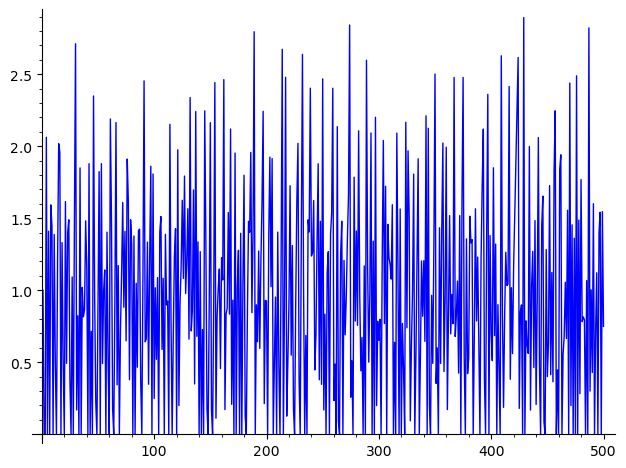

In [3]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

D = delta_qexp(3580) 
h_list=[1]+[nth_prime(k+1)-nth_prime(k)-2 for k in range(1,501)]
def h(n):
    return h_list[n]
j_list=j_sequence_from_h(h_list)
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

with open('/Users/barrybrent/data2/run16may26no6.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 
with open('/Users/barrybrent/data2/run16may26no7.txt', 'wb') as wfile:
    pickle.dump(h_list, wfile)
with open('/Users/barrybrent/data2/run16may26no8.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run16may26no9.txt', 'wb') as wfile: #this might be heavy
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run16may26no10.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile)

In [4]:
with open('/Users/barrybrent/data2/run16may26no9a.txt', 'wb') as wfile:
    pickle.dump(chi_list[:100], wfile)
with open('/Users/barrybrent/data2/run16may26no9b.txt', 'wb') as wfile:
    pickle.dump(chi_list[101:200], wfile)
with open('/Users/barrybrent/data2/run16may26no9c.txt', 'wb') as wfile:
    pickle.dump(chi_list[201:300], wfile)
with open('/Users/barrybrent/data2/run16may26no9d.txt', 'wb') as wfile:
    pickle.dump(chi_list[301:400], wfile)
with open('/Users/barrybrent/data2/run16may26no9e.txt', 'wb') as wfile:
    pickle.dump(chi_list[401:500], wfile)

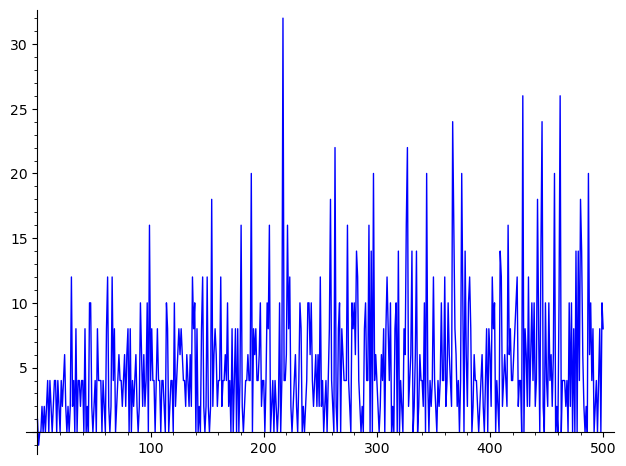

In [5]:
p = list_plot(h_list, plotjoined=True, axes_labels=['', ''])
p.show()